In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\5_comp
scenario=5comp_equal  K_MODEL=5  K_TRUE=5
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full, unbounded  +  Chebyshev-filtered) ──────────
# Two grids are built per parameter and carried through every cell below. Neither
# uses the True DGP to set bounds beyond including it in the envelope/moments -
# it stays an overlay only.
#   "Full"                   - mc.build_grids_full: raw min/max envelope over EVERY
#                               component (all K, incl. surplus/empty ones) of every
#                               sampler and the True DGP. Nothing is excluded, so every
#                               metric integrates over the ENTIRE marginal - but a
#                               diffuse empty component (K_MODEL > K_TRUE) or a sampler
#                               exploring far off the high-density area can stretch this
#                               range enormously and squash the real mass into a few
#                               pixels.
#   "Chebyshev (k=5, >=96%)" - mc.build_grids_chebyshev: clipped to each model's own
#                               AGGREGATE mixture [mean - 5*std, mean + 5*std] (Eq.
#                               5.5.2). Chebyshev's inequality, P(|X-mean|>=k*std) <=
#                               1/k**2, holds for ANY distribution with finite variance
#                               (no normality/unimodality assumption - the invariant
#                               marginal is itself a mixture) - so >=1 - 1/5**2 = 96% of
#                               each model's own marginal mass is guaranteed to lie
#                               inside its window, trimming the outlier-driven tails of
#                               "Full" while keeping a distribution-free coverage bound.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-398.57, +525.52]
  Alt2       [-206.46, +237.52]
  Alt3       [-151.73, +146.85]
  Price      [-155.79, +133.95]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-8.90, +13.71]
  Alt2       [-13.43, +15.91]
  Alt3       [-15.86, +17.14]
  Price      [-22.00, +19.72]


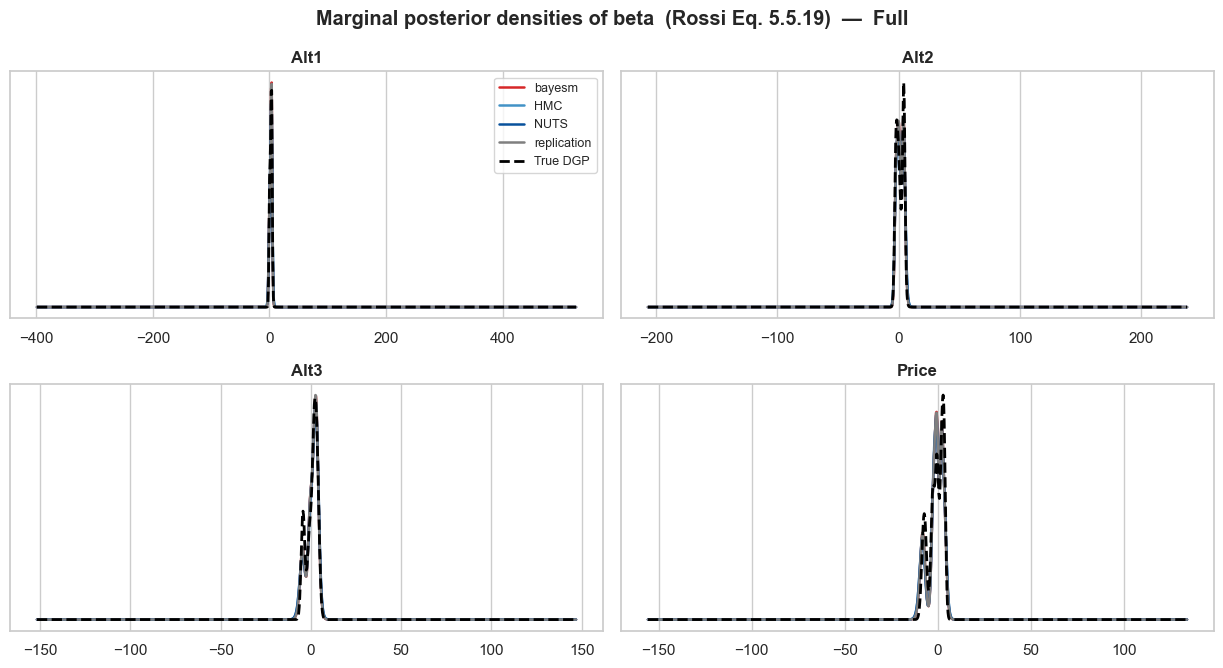

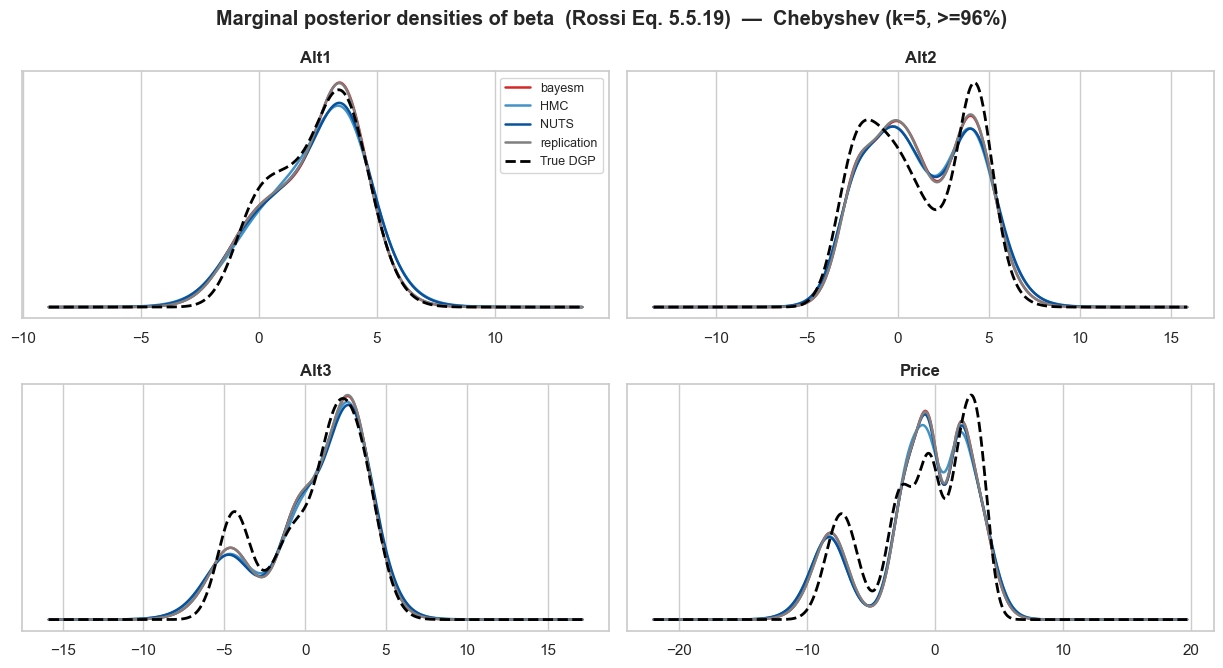

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev-filtered ──────────
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light). One figure per grid pass.
# `marginal_density` is O(R*K*n_grid) per model - computed ONCE per (model, grid)
# pass here and cached in DENS/DENS_TRUE so Cells 5 and 7 reuse it instead of
# recomputing it internally.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  \u2014  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev-filtered ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them. The two passes differ only in the integration grid built in Cell 3;
# distances typically shrink under "Chebyshev" once the diffuse/outlier tails that
# dominate "Full" are clipped out. Reuses the densities cached in Cell 4 (DENS,
# DENS_TRUE) rather than recomputing marginal_density a second time.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:265: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06848  0.02593  0.00442  0.04015       0.11081
            Alt2     0.07071  0.02071  0.00497  0.08552       0.23853
            Alt3     0.09106  0.05169  0.00768  0.06430       0.20337
            Price    0.14324  0.10232  0.01961  0.14162       0.38789
HMC         Alt1     0.09763      inf  0.00866  0.06248       0.19796
            Alt2     0.08616      inf  0.00719  0.09236       0.25000
            Alt3     0.11029      inf  0.01098  0.06828       0.26122
            Price    0.15960      inf  0.02395  0.15114       0.41077
NUTS        Alt1     0.09251  0.05240  0.00797  0.06342       0.19620
            Alt2     0.08371      inf  0.00687  0.09133       0.24730
            Alt3     0.11424      inf  0.01188  0.07969       0.27049
            Price    0.15774      inf  0.02341  0.14768       0.41274
replication Alt1     0.06775  0.02537  0.00433  0.03817       0.10668
            Alt2     0.07001  0.02028  0.00488  0.08479       0.23674
            Alt3     0.09031  0.04992  0.00756  0.06369       0.20416
            Price    0.14240  0.10104  0.01938  0.14157       0.38693

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06848  0.02593  0.00442  0.04202       0.10895
            Alt2     0.07071  0.02071  0.00497  0.08560       0.23720
            Alt3     0.09106  0.05167  0.00768  0.06426       0.20296
            Price    0.14324  0.10232  0.01961  0.14133       0.38728
HMC         Alt1     0.09676  0.06379  0.00854  0.06247       0.18822
            Alt2     0.08565  0.03699  0.00713  0.09304       0.24594
            Alt3     0.11001  0.08934  0.01093  0.06820       0.25871
            Price    0.15955  0.14288  0.02394  0.15160       0.40947
NUTS        Alt1     0.09246  0.05071  0.00796  0.06440       0.19447
            Alt2     0.08368  0.03184  0.00687  0.09208       0.24575
            Alt3     0.11422  0.08944  0.01188  0.07996       0.27004
            Price    0.15774  0.13527  0.02341  0.14769       0.41172
replication Alt1     0.06775  0.02537  0.00433  0.04031       0.10475
            Alt2     0.07001  0.02028  0.00488  0.08466       0.23542
            Alt3     0.09031  0.04991  0.00756  0.06358       0.20375
            Price    0.14240  0.10104  0.01938  0.14130       0.38635

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent - computed analytically from the draws, not by integrating over
# either grid - so this runs once for both passes above.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.346,2.402,2.396,2.346,2.388
Alt2,1.318,1.333,1.346,1.318,1.142
Alt3,0.634,0.644,0.649,0.638,0.560
Price,-1.127,-1.139,-1.149,-1.125,-1.000


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,4.162,5.113000,4.666000,4.153,3.603
Alt2,7.811,8.500000,8.374000,7.802,8.496
Alt3,10.200,10.890000,10.858000,10.158,9.511
Price,16.632,17.403999,17.311001,16.586,15.138


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series - Full vs Chebyshev-filtered ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter. The density mask
# (density_threshold) is relative to each grid's own peak, so both passes restrict to
# their own high-density region even though "Full" spans a much wider range. Reuses
# the densities cached in Cell 4 (DENS) rather than recomputing marginal_density a
# third time just to rebuild the mask.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for label, grids in GRIDS.items():
    print(f"=== Grid: {label} ===")
    for m in models:
        print(f"--- {m['name']} ---")
        display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40,
                                               marg=DENS[label][m["name"]]).round(3))

=== Grid: Full ===
--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,1,661.755,661.755,1.002,1.002
Alt2,1,997.766,997.766,1.002,1.002
Alt3,2,511.663,884.519,1.000,1.000
Price,2,263.825,2119.594,1.010,1.006


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,1,21.875,21.875,1.064,1.064
Alt2,1,61.745,61.745,1.035,1.035
Alt3,2,5.927,105.817,1.249,1.125
Price,2,4.047,111.518,1.422,1.212


--- NUTS ---


...

,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,22,6.888,201.741,1.209,1.073
Alt2,20,7.720,251.677,1.179,1.047
Alt3,21,5.218,247.660,1.291,1.072
Price,19,3.670,232.081,1.499,1.073


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,21,1449.119,3190.971,1.004,1.002
Alt2,19,1488.710,2439.030,1.002,1.001
Alt3,20,1299.305,2666.126,1.001,1.001
Price,19,904.012,3116.277,1.003,1.001


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,20,517.037,1659.390,1.008,1.003
Alt2,19,618.937,1284.938,1.008,1.002
Alt3,19,520.081,1328.862,1.005,1.002
Price,19,220.884,1545.332,1.011,1.004


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
# Grid-independent, like Cell 6 - runs once.
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - Two grids are compared throughout: 'Full' (unbounded envelope over every")
print("   component of every sampler + True DGP - nothing excluded, but can be very")
print("   wide when a sampler explores far off the high-density area or K_MODEL >")
print("   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate")
print("   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%")
print("   of that model's own marginal mass is retained, regardless of shape).")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC.")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean    1456.5281  1.0013
      Var     1291.8730  1.0005
Alt2  Mean    3141.4126  1.0003
      Var      953.2706  1.0014
Alt3  Mean    1903.3343  1.0000
      Var      574.8830  1.0010
Price Mean    1767.4349  1.0017
      Var      399.4535  1.0080

--- HMC ---


ESS    Rhat
param moment                   
Alt1  Mean     460.8056  1.0039
      Var       54.8493  1.0354
Alt2  Mean    1058.0159  1.0037
      Var       57.1917  1.0340
Alt3  Mean     519.6881  1.0033
      Var      219.7666  1.0069
Price Mean     914.6139  1.0014
      Var      265.1288  1.0028

--- NUTS ---


ESS    Rhat
param moment                   
Alt1  Mean    3101.2086  1.0014
      Var     2093.7709  1.0016
Alt2  Mean    5801.7934  1.0002
      Var     1856.0511  1.0015
Alt3  Mean    4162.7078  1.0001
      Var     2079.5370  1.0011
Price Mean    5569.7530  1.0001
      Var     1416.7263  1.0016

--- replication ---


ESS    Rhat
param moment                   
Alt1  Mean    1682.9013  1.0035
      Var     1285.1650  1.0021
Alt2  Mean    3010.5850  1.0002
      Var     1159.2274  1.0064
Alt3  Mean    1912.4234  1.0002
      Var      763.5695  1.0026
Price Mean    2299.5674  1.0013
      Var      406.2647  1.0086


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - Two grids are compared throughout: 'Full' (unbounded envelope over every
   component of every sampler + True DGP - nothing excluded, but can be very
   wide when a sampler explores far off the high-density area or K_MODEL >
   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate
   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%
   of that model's own marginal mass is retained, regardless of shape).
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   th